# Домашнее задание 4 - Непараметрические критерии


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import hashlib
import collections
from statsmodels.stats.descriptivestats import sign_test

plt.style.use('ggplot')
%matplotlib inline

##Задача 1 (5 баллов)




1.   Сгенерить самостоятельно 2 распределения, нормальное с любыми параметрами и размером 1000 и биномиальное с параметрами 1, 0.5 и размером 100
2.   Для каждого распределения
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения имееют общее распределение с помощью критерия однородности Смирнова
3.   Собрать новую выборку из ваших 2 сгенирированных распределений. Для этого взять случайных 900 элементов из нормального распределения и добавить к ним выборку с биномиальным распределением, чтобы снова получили выборки из 1000 элементов
4.   Для новой "собранной выборки"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
5.  Из выборки с нормальным распределением получить новую выборку. Сделаем это с помощью "докидывания эффекта". Взять текущую выборку с нормальным распределением и рандомные 500 элементов увеличить на 5%, остальные оставим без изменений
6. Для новой выборки с "докинутым эффектом"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения(изначальное нормальное из п1 и полученное в п5) имееют общее распределение с помощью критерия однородности Смирнова





















#### Пункт 1

In [ ]:
x_norm = stats.norm(loc=5, scale=3).rvs(1000)
x_binom = stats.binom(1, 0.5).rvs(100)

#### Пункт 2

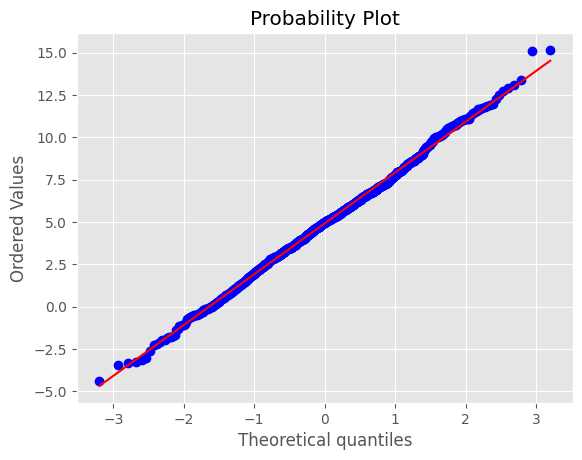

In [ ]:
# Нормальное распределение
stats.probplot(x_norm, dist="norm", plot=plt);

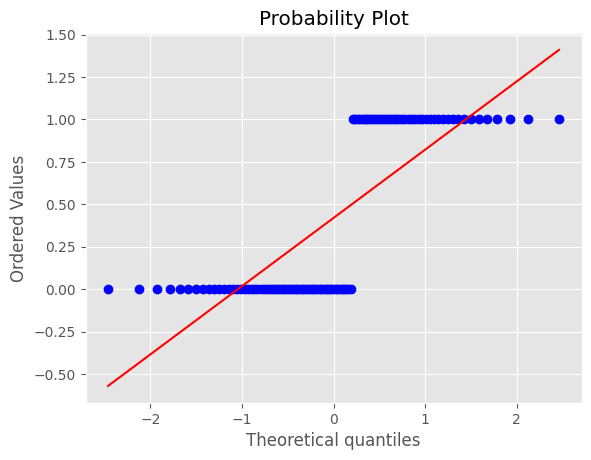

In [ ]:
# Биномиальное распределение
stats.probplot(x_binom, dist="norm", plot=plt);

In [ ]:
def printKolmAndShapiro(data):
  p_value_Kolm = stats.kstest(data, 'norm', args=(data.mean(), data.std(ddof=1))).pvalue
  p_value_Shapiro = stats.shapiro(data).pvalue
  print(f'Тест Колмогорова (p_value): {p_value_Kolm:.4f}\nТест Шапиро-Уилка (p_value): {p_value_Shapiro:.4f}')

In [ ]:
# Для нормального распределения
print(f'Нормальное распределение:')
printKolmAndShapiro(x_norm)

Нормальное распределение:
Тест Колмогорова (p_value): 0.5256
Тест Шапиро-Уилка (p_value): 0.3846


p_value в обоих тестах достаточно высоко.

In [ ]:
# Тест биномиального распределения
print(f'Биномиальное распределение:')
printKolmAndShapiro(x_binom)

Биномиальное распределение:
Тест Колмогорова (p_value): 0.0000
Тест Шапиро-Уилка (p_value): 0.0000


p_value в обоих тестах близко к нулю.

#### Пункт 3

In [ ]:
x_norm_binom_effect = np.random.choice(x_norm, replace=False, size=900)
x_norm_binom_effect = np.concatenate((x_norm_binom_effect, x_binom))
x_norm_binom_effect

array([ 4.71320663e+00,  7.80623911e+00,  5.14800775e+00,  5.07968214e+00,
        5.36054642e+00,  6.64477780e+00,  9.76933491e+00,  9.97351387e+00,
        5.39450559e+00,  1.00485342e+01,  2.25107925e+00,  4.84655281e+00,
        2.52834899e+00,  6.54412554e+00,  3.96742848e+00,  2.46464113e+00,
        5.14270783e+00,  1.00360294e+01,  7.16159956e+00,  2.73078355e+00,
       -1.30792166e-01,  1.16829168e+01,  8.93437657e+00,  3.25343208e+00,
        5.46855302e+00,  4.26038821e+00,  8.51469524e+00,  6.74014047e+00,
        6.69881345e+00,  1.10784582e+01,  2.17988278e+00,  1.14094131e+01,
        4.22992764e+00,  4.88274991e+00,  6.63299367e+00,  2.97420019e+00,
        5.13208996e+00,  4.38383346e+00,  4.26566567e+00,  5.63223197e+00,
        3.88466861e+00,  7.68461429e+00,  8.61595365e+00,  6.78978428e+00,
        8.75078676e-01,  5.30601268e+00,  6.74103815e-01,  1.75722498e+00,
        2.47141037e+00,  5.78437049e+00,  7.61766529e+00,  3.50106372e+00,
        9.42985767e+00,  

#### Пункт 4

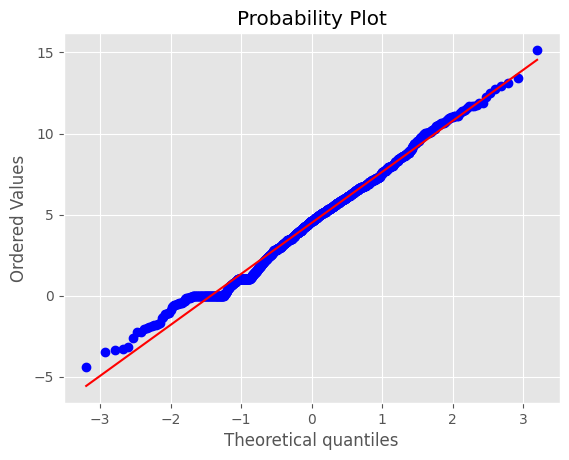

In [ ]:
# Нормальное распределение с эффектом биномиального
stats.probplot(x_norm_binom_effect, dist="norm", plot=plt);

In [ ]:
# Для нормальное распределения с эффектом биномиального
print(f'Нормальное распределение с эффектом биномиального:')
printKolmAndShapiro(x_norm_binom_effect)

Нормальное распределение с эффектом биномиального:
Тест Колмогорова (p_value): 0.0052
Тест Шапиро-Уилка (p_value): 0.0000


Тест Колмогорова показывает, что при уровне стат значимости в 0.01 гипотеза была бы принята, а при 0.05 - отклонена. При этом тест Шапиро-Уилка говорит о том, что гипотеза должна быть отклонена

#### Пункт 5

In [ ]:
indices_to_increase = np.random.choice(len(x_norm), size=500, replace=False)
x_norm_affected = x_norm.copy()
x_norm_affected[indices_to_increase] *= 1.05
x_norm_affected

array([ 8.57490933e-01,  1.15153795e+01,  6.62381058e+00,  1.17082300e+01,
        3.81394866e+00,  6.16658767e+00,  4.50955266e+00,  3.37779569e+00,
        5.37521525e+00,  7.38727421e-01,  8.68980203e+00,  2.37540564e+00,
        1.12611353e+01,  3.60620123e+00,  6.32801141e+00,  2.14362603e+00,
        4.07890205e+00,  7.40842032e+00,  1.16784853e+01,  9.02996507e+00,
        4.56627230e-01,  4.77097005e+00,  2.22600228e+00,  3.07243186e+00,
        9.36931115e+00,  1.97715184e+00,  8.62426886e+00,  4.92393792e+00,
        3.81815309e+00,  2.53937348e+00,  1.60617681e+00,  7.46395998e+00,
        5.45517949e+00,  3.11029407e+00,  7.34531327e+00,  3.68771968e+00,
        2.03146555e+00,  7.66962789e+00,  3.11397567e+00,  6.27554888e+00,
       -1.39436189e+00,  7.22939962e+00,  8.51067858e+00,  7.09751998e+00,
        4.98409831e+00,  5.10097628e+00,  3.34925763e+00,  1.21212003e+00,
        2.51166590e+00,  2.82105778e+00,  5.03936684e+00,  1.05509609e+01,
        2.21392769e+00,  

#### Пункт 6

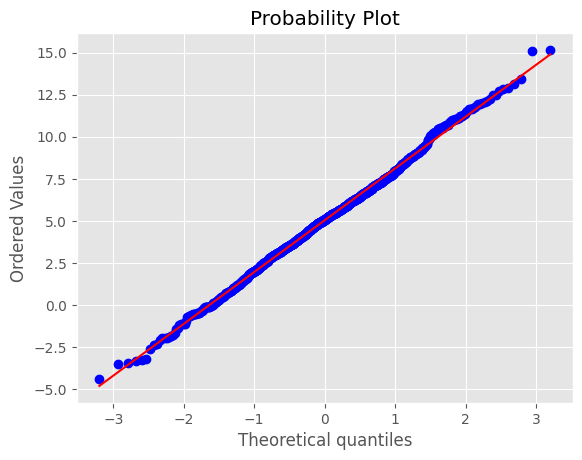

In [ ]:
# Нормальное распределение с доп эффектом
stats.probplot(x_norm_affected, dist="norm", plot=plt);

In [ ]:
# Для нормальное распределения с доп эффектом
print(f'Нормальное распределение с доп эффектом:')
printKolmAndShapiro(x_norm_affected)

Нормальное распределение с доп эффектом:
Тест Колмогорова (p_value): 0.7376
Тест Шапиро-Уилка (p_value): 0.3010


p_value достаточно высоки, принимаем гипотезу о нормальности распределения.

In [ ]:
stats.ks_2samp(x_norm_affected, x_norm).pvalue

0.6854967337920594

p_value достаточно высоко, что говорит о том, что полученное распределение вероятно совпадает с распределением из п.1 (с нормальным).

## Задача 2 (4 балла)

Для данных из файла employees.xls постройте гистограмму для переменной SALARY. Проверьте нормальность этих данных с помощью:
  * Q-Q plot
  * Критерия Колмогорова
  * Критерия Шапиро-Уилка


In [ ]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/employees.xls >> employees.xls

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 26624  100 26624    0     0  78366      0 --:--:-- --:--:-- --:--:-- 78305


In [ ]:
import pandas as pd

df = pd.read_excel('employees.xls')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  100 non-null    object
 1   GENDER      100 non-null    object
 2   DEPART      100 non-null    object
 3   EDUC        100 non-null    object
 4   AGE         100 non-null    int64 
 5   HEIGHT      100 non-null    int64 
 6   SENIOR      100 non-null    int64 
 7   SALARY      100 non-null    int64 
 8   INI_PROF    100 non-null    int64 
 9   CUR_PROF    100 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 7.9+ KB


In [ ]:
df.head()

,Unnamed: 0,GENDER,DEPART,EDUC,AGE,HEIGHT,SENIOR,SALARY,INI_PROF,CUR_PROF
0,Alexander,Female,Ship,College,22,63,4,23400,82,90
1,Arcones,Male,Package,College,49,65,17,40400,89,123
2,Barber,Male,Bake,College,36,67,8,29400,77,93
3,Barrera,Male,Package,HS,37,67,3,24800,102,108
4,Bester,Male,Ship,Grad,43,66,11,31200,82,104


Построим гистограмму:

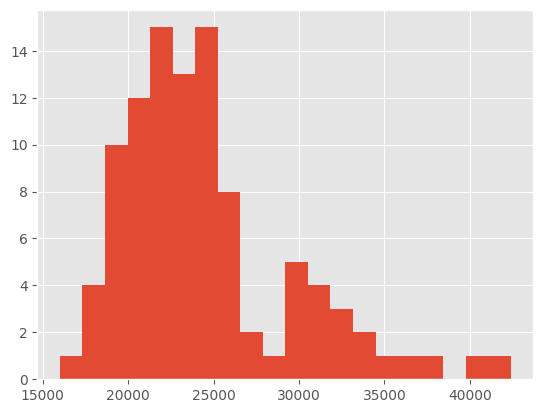

In [ ]:
salary = df['SALARY'].to_numpy()
plt.hist(salary, bins=20)
plt.show()

С виду распределение не похоже на нормальное. Проверим с помощью Q-Q plot и непараметрических критериев:

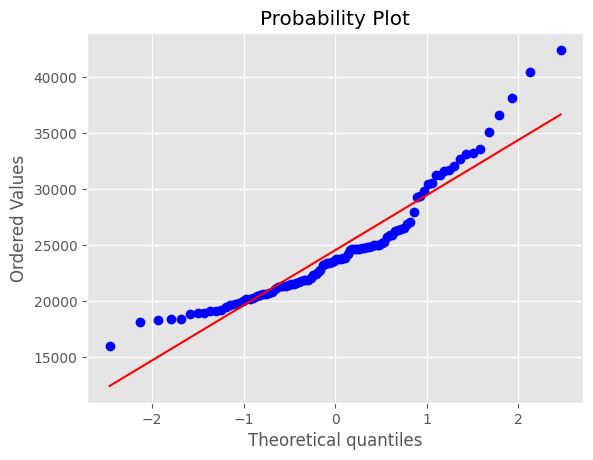

In [ ]:
stats.probplot(salary, dist="norm", plot=plt);

In [ ]:
printKolmAndShapiro(salary)

Тест Колмогорова (p_value): 0.0168
Тест Шапиро-Уилка (p_value): 0.0000


По Q-Q plot нельзя сказать, что распределение нормальное (далеко не все синие точки лежат на красной линии), как и по критерию Шапиро-Уилка (p-value близко к 0). Однако по критерию Колмогорова при уровне стат значимости в 0.01 гипотеза не отвергнется.

## Задача 3 (3 балла)

Для данных из файла employees.xls проверить с помощью критерия знаков и рангового критерия гипотезу что медианная зарплата равна 25000

Построим гистограмму и опишем данные:

In [ ]:
df['SALARY'].describe()

,SALARY
count,100.000000
mean,24522.000000
std,5105.801414
min,16000.000000
25%,21025.000000
50%,23650.000000
75%,26225.000000
max,42400.000000


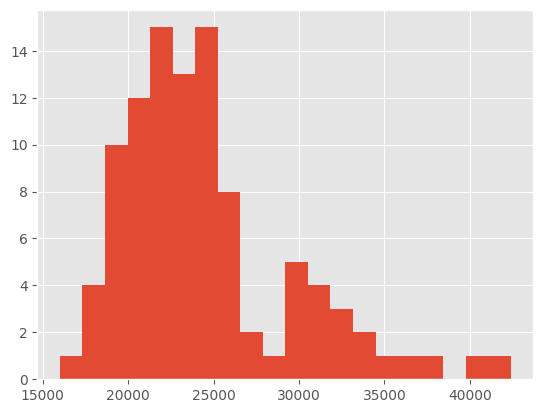

In [ ]:
plt.hist(salary, bins=20)
plt.show()

Выглядит так, будто медиана ощутимо меньше. Установим гипотезу:

$H_0\colon Med(X) = 25000$

$H_1\colon Med(X) \ne 25000$

Критерий знаков:

In [ ]:
x = df['SALARY'].values
_, pvalue = sign_test(x, mu0=25000)
pvalue

0.000490157948963301

p_value достаточно мало (меньше 0.01), отвергаем гипотезу.

Ранговый критерий Уилкоксона:

In [ ]:
_, pvalue = stats.wilcoxon(x - 25000)
pvalue

0.04131952571720401

При уровне стат значимости в 0.01 гипотеза была бы принята, при уровне в 0.05 - отвергнута.

## Задача 4 (3 балла)

В файле anorexia.txt записан вес пациентов до и после начала терапии от анорексии. С помощью критерия знаков и рангового критерия проверить, была ли эффективна данная терапия

In [ ]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/anorexia.txt >> anorexia.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   355  100   355    0     0    936      0 --:--:-- --:--:-- --:--:--   939


In [ ]:
df = pd.read_csv('anorexia.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Before  29 non-null     float64
 1   After   29 non-null     float64
dtypes: float64(2)
memory usage: 592.0 bytes


In [ ]:
df.head()

,Before,After
0,80.5,82.2
1,84.9,85.6
2,81.5,81.4
3,82.6,81.9
4,79.9,76.4


Построим гистограмму и опишем данные:

In [ ]:
df.describe()

,Before,After
count,29.000000,29.000000
mean,82.689655,85.696552
std,4.845495,8.351924
min,70.000000,71.300000
25%,80.400000,81.900000
50%,82.600000,83.900000
75%,85.000000,90.900000
max,94.900000,103.600000


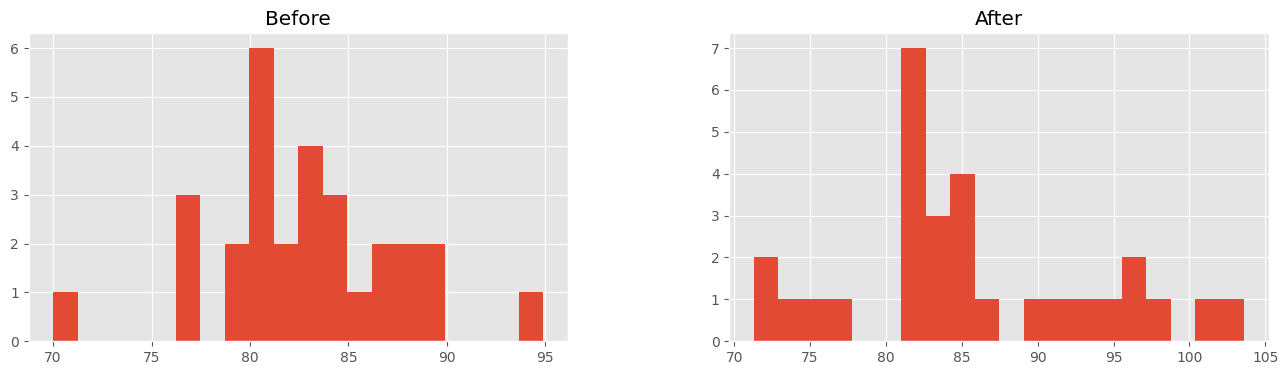

In [ ]:
df.hist(bins = 20, figsize=(16,4))
plt.show()

По гистограммам не совсем понятно, увеличился ли в общем вес. По медиане - немного. Рассмотрим критерии:

Критерий знаков:

$H_0\colon P(X > Y) = 0.5$

$H_1\colon P(X > Y) \ne 0.5$

In [ ]:
_, pvalue = sign_test(df['After'] - df['Before'])
pvalue

0.26493089646101

p_value достаточно большое, принимаем нулевую гипотезу.

Ранговый критерий Уилкоксона:

$H_0\colon Med(X - Y) = 0$

$H_1\colon Med(X - Y) \ne 0$

In [ ]:
_, pvalue = stats.wilcoxon(df['After'], df['Before'])
pvalue

0.06551516801118851

p_value достаточно большое (> 0.05), принимаем нулевую гипотезу.

## Задача 5 (3 балла)

В файле seattle.txt записаны цены на объекты недвижимости в одном районе из районов Сиетла в 2001 и 2002 году (объекты выбирались случайно). Изменились ли средние цены в этом районе за год? Проверить это с помощью критерия знаков и рангового критерия

In [ ]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/seattle.txt >> seattle.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   996  100   996    0     0   2919      0 --:--:-- --:--:-- --:--:--  2912


In [ ]:
df = pd.read_csv('seattle.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   100 non-null    float64
 1   Year    100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [ ]:
df.head()

,Price,Year
0,142.0,2002
1,232.0,2002
2,132.5,2002
3,200.0,2002
4,362.0,2002


Построим гистограмму и опишем данные:

In [ ]:
prices_2001 = df[df['Year'] == 2001]['Price']
prices_2002 = df[df['Year'] == 2002]['Price']
df_by_year = pd.DataFrame({'Year_2001': prices_2001, 'Year_2002': prices_2002})
df_by_year.describe()

,Year_2001,Year_2002
count,50.000000,50.000000
mean,288.926540,329.257140
std,157.777757,316.830045
min,50.000000,50.000000
25%,190.250000,176.200000
50%,260.800000,244.925000
75%,406.737500,328.625000
max,710.000000,1850.000000


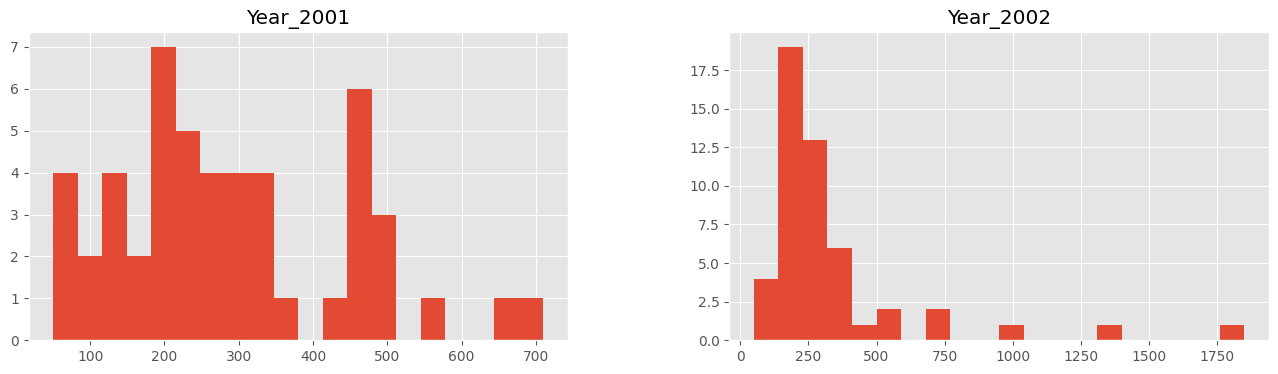

In [ ]:
df_by_year.hist(bins = 20, figsize=(16,4))
plt.show()

Медиана выглядит уменьшившейся, однако появились выбросы с большими значениями.

Нельзя использовать критерий знаков, так как он предназначен для связанных выборок. Установим гипотезу для критерия Уилкоксона:

$H_0\colon Med(X - Y) = 0$

$H_1\colon Med(X - Y) \ne 0$

In [ ]:
_, pvalue = stats.wilcoxon(prices_2001, prices_2002)
pvalue

0.8109402812359416

p_value достаточно большое, не отвергаем нулевую гипотезу.

## Задача 6 (3 балла)

В рамках исследования эффективности лекарства
пациенты с синдромом дефицита внимания и гиперактивностью в течение недели принимали либо лекарство, либо плацебо. В конце недели каждый пациент проходил тест на способность к подавлению импульсивных поведенческих реакций. Был ли эффект от применения лекарства? Данные находятся в файле methylphenidate.txt.

In [ ]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/methylphenidate.txt >> methylphenidate.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   168  100   168    0     0    524      0 --:--:-- --:--:-- --:--:--   523


In [ ]:
df = pd.read_csv('methylphenidate.txt', sep=' ')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Placebo          24 non-null     int64
 1   Methylphenidate  24 non-null     int64
dtypes: int64(2)
memory usage: 512.0 bytes


In [ ]:
df.head()

,Placebo,Methylphenidate
0,57,62
1,27,49
2,32,30
3,31,34
4,34,38


Построим гистограмму и опишем данные:

In [ ]:
df.describe()

,Placebo,Methylphenidate
count,24.000000,24.000000
mean,39.750000,44.708333
std,11.314669,12.319935
min,26.000000,29.000000
25%,33.000000,35.000000
50%,36.000000,42.500000
75%,44.500000,52.500000
max,71.000000,77.000000


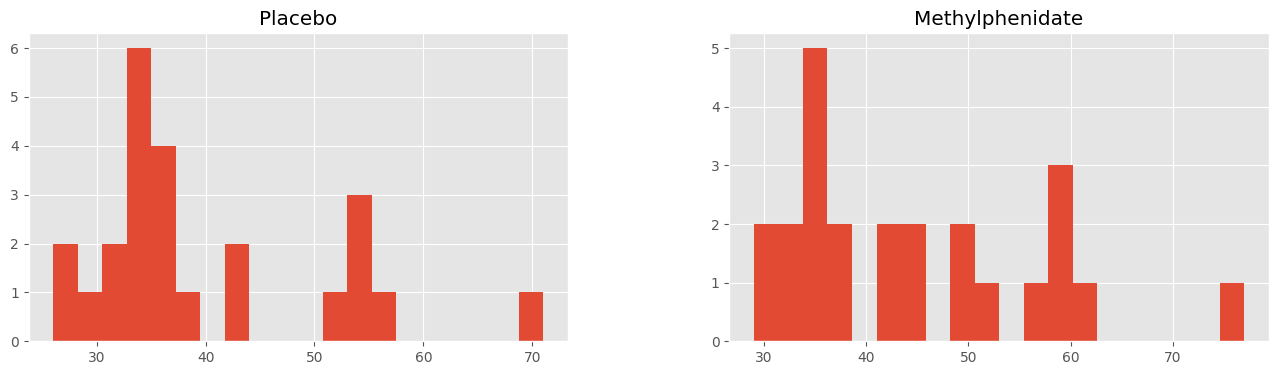

In [ ]:
df.hist(bins = 20, figsize=(16,4))
plt.show()

Выглядит так, будто медиана выросла. Рассмотрим критерии:

Критерий знаков:

$H_0\colon P(X > Y) = 0.5$

$H_1\colon P(X > Y) \ne 0.5$

In [ ]:
_, pvalue = sign_test(df['Methylphenidate'] - df['Placebo'])
pvalue

0.06391465663909912

p_value достаточно большое (> 0.05), принимаем нулевую гипотезу.

Ранговый критерий Уилкоксона:

$H_0\colon Med(X - Y) = 0$

$H_1\colon Med(X - Y) \ne 0$

In [ ]:
_, pvalue = stats.wilcoxon(df['Methylphenidate'], df['Placebo'])
pvalue

0.002814650535583496

По ранговому критерию H0 была бы отклонена (p_value < 0.01).

## Задача 7 (2 балла)


1.   Сгенерировать выборки с нормальным распределением без выбросов, докинуть эффект на одну из них равномерно и с помощью распределения
2.   То же, что и в п1, но выборки с выбросами сделать
3.   Для случаев из п1 и п2 бутстрэпом оценить: среднее, медиану, 25% перцентиль, построить доверительные интервалы для статистик (речь о разницах средних/медиан/перцентилей для групп)
4.   Для случаев из п1 и п2 оценить среднее т-тестом и Манном-Уитни. Сравнить с результатами бутстрэпа. Сделать выводы. Сравниваем точечные оценки (на бутстрэпе их тоже считаем)

Примечание:
- Бутстреп считать минимум на 1000 итераций
- Для докидывания эффекта с помощью распределения возьмите распределение из stats, параметры задаются исходя из параметров изначального вектора и желаемого эффекта


### Пункт 1

In [ ]:
# Выборка из нормального распределения
x_norm = stats.norm(loc=3, scale=5).rvs(1000)

# Равномерный эффект
x_norm_const_effect = x_norm.copy()
x_norm_const_effect *= 1.5

# Эффект от экспоненциального распределения
x_expon = stats.expon(loc=3, scale=5).rvs(1000)
x_norm_expon_effect = x_norm.copy()
x_norm_expon_effect += x_expon

### Пункт 2

In [ ]:
indices_to_increase = np.random.choice(len(x_norm), size=25, replace=False)

# Выборка из нормального распределения с выбросами
x_norm_outliers = x_norm.copy()
x_norm_outliers[indices_to_increase] *= 1000

indices_to_increase = np.random.choice(len(x_norm), size=25, replace=False)

# Равномерный эффект с выбросами
x_norm_const_effect_outliers = x_norm_const_effect.copy()
x_norm_const_effect_outliers[indices_to_increase] *= 1000

indices_to_increase = np.random.choice(len(x_norm), size=25, replace=False)

# Эффект от экспоненциального распределения с выбросами
x_norm_expon_effect_outliers = x_norm_expon_effect.copy()
x_norm_expon_effect_outliers[indices_to_increase] *= 1000

### Пункт 3

In [ ]:
def get_bootstrap_array(arr):
    return np.random.choice(arr, replace=True, size=len(arr))

def calc_bootstrap_stats(samples, n_bootstrap=1000):
    means = np.empty(n_bootstrap)
    medians = np.empty(n_bootstrap)
    perc_25 = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
      sample = get_bootstrap_array(samples)
      means[i] = np.mean(sample)
      medians[i] = np.median(sample)
      perc_25[i] = np.percentile(sample, 25)
    return means, medians, perc_25

def calc_interval(aggregated_stats, testing_distr=stats.norm, alpha=0.05):
  alpha_two_sides = alpha / 2
  quantile = testing_distr.ppf(1 - alpha_two_sides)

  sigma = aggregated_stats.std()
  mu = aggregated_stats.mean()

  coef = quantile * (sigma / np.sqrt(len(aggregated_stats)))
  return mu - coef, mu + coef

In [ ]:
def print_if_has_diff(left, right):
  if left <= 0 and right >= 0:
    print(f'Доверительный интервал включает 0, так что статистически значимой разницы не обнаружено')
  else:
    print(f'Обнаружена статистически значимая разница')

In [ ]:
def bootstrap_and_print_intervals(samples, testing_distr=stats.norm, n_bootstrap=1000, alpha=0.05):
  means, medians, perc_25 = calc_bootstrap_stats(samples, n_bootstrap)
  means_interval = calc_interval(means, testing_distr, alpha)
  medians_interval = calc_interval(medians, testing_distr, alpha)
  perc_25_interval = calc_interval(perc_25, testing_distr, alpha)

  print(f'Оценка среднего: {means.mean():.2f}')
  print(f'Доверительный интервал для среднего: [{means_interval[0]:.2f}, {means_interval[1]:.2f}]')
  print_if_has_diff(means_interval[0], means_interval[1])

  print(f'Оценка медианы: {medians.mean():.2f}')
  print(f'Доверительный интервал для медианы: [{medians_interval[0]:.2f}, {medians_interval[1]:.2f}]')
  print_if_has_diff(medians_interval[0], medians_interval[1])

  print(f'Оценка 25го перцентиля: {perc_25.mean():.2f}')
  print(f'Доверительный интервал для 25го перцентиля: [{perc_25_interval[0]:.2f}, {perc_25_interval[1]:.2f}]')
  print_if_has_diff(perc_25_interval[0], perc_25_interval[1])

In [ ]:
norm_to_const_effect = x_norm_const_effect - x_norm
norm_to_expon_effect = x_norm_expon_effect - x_norm

norm_to_const_effect_outliers = x_norm_const_effect_outliers - x_norm_outliers
norm_to_expon_effect_outliers = x_norm_expon_effect_outliers - x_norm_outliers

print(f'Для разницы нормального распределения и нормального распределения с константным эффектом:')
bootstrap_and_print_intervals(norm_to_const_effect)
print(f'\nДля разницы нормального распределения и нормального распределения с эффектом экспоненциального:')
bootstrap_and_print_intervals(norm_to_expon_effect)
print(f'\nДля разницы нормального распределения с выбросами и нормального распределения с константным эффектом с выбросами:')
bootstrap_and_print_intervals(norm_to_const_effect_outliers)
print(f'\nДля разницы нормального распределения с выбросами и нормального распределения с эффектом экспоненциального с выбросами:')
bootstrap_and_print_intervals(norm_to_expon_effect_outliers)

Для разницы нормального распределения и нормального распределения с константным эффектом:
Оценка среднего: 1.52
Доверительный интервал для среднего: [1.51, 1.52]
Обнаружена статистически значимая разница
Оценка медианы: 1.58
Доверительный интервал для медианы: [1.58, 1.59]
Обнаружена статистически значимая разница
Оценка 25го перцентиля: -0.27
Доверительный интервал для 25го перцентиля: [-0.27, -0.26]
Обнаружена статистически значимая разница

Для разницы нормального распределения и нормального распределения с эффектом экспоненциального:
Оценка среднего: 7.98
Доверительный интервал для среднего: [7.97, 7.99]
Обнаружена статистически значимая разница
Оценка медианы: 6.47
Доверительный интервал для медианы: [6.46, 6.48]
Обнаружена статистически значимая разница
Оценка 25го перцентиля: 4.62
Доверительный интервал для 25го перцентиля: [4.61, 4.62]
Обнаружена статистически значимая разница

Для разницы нормального распределения с выбросами и нормального распределения с константным эффектом 

### Пункт 4

In [ ]:
def print_equality_ttest_mann(samples1, samples2, alpha=0.05):
  ttest_p_value = stats.ttest_ind(samples1, samples2).pvalue
  mann_p_value = stats.mannwhitneyu(samples1, samples2).pvalue

  if ttest_p_value > alpha:
    print(f'По t-тесту разница между выборками не является статистически значимой')
  else:
    print(f'По t-тесту разница между выборками статистически значима')

  if mann_p_value > alpha:
    print(f'По критерию Манна-Уитни разница между выборками не является статистически значимой')
  else:
    print(f'По критерию Манна-Уитни разница между выборками статистически значима')

In [ ]:
print(f'Для разницы нормального распределения и нормального распределения с константным эффектом:')
print_equality_ttest_mann(x_norm_const_effect, x_norm)
print(f'\nДля разницы нормального распределения и нормального распределения с эффектом экспоненциального:')
print_equality_ttest_mann(x_norm_expon_effect, x_norm)
print(f'\nДля разницы нормального распределения с выбросами и нормального распределения с константным эффектом с выбросами:')
print_equality_ttest_mann(x_norm_const_effect_outliers, x_norm_outliers)
print(f'\nДля разницы нормального распределения с выбросами и нормального распределения с эффектом экспоненциального с выбросами:')
print_equality_ttest_mann(x_norm_expon_effect_outliers, x_norm_outliers)

Для разницы нормального распределения и нормального распределения с константным эффектом:
По t-тесту разница между выборками статистически значима
По критерию Манна-Уитни разница между выборками статистически значима

Для разницы нормального распределения и нормального распределения с эффектом экспоненциального:
По t-тесту разница между выборками статистически значима
По критерию Манна-Уитни разница между выборками статистически значима

Для разницы нормального распределения с выбросами и нормального распределения с константным эффектом с выбросами:
По t-тесту разница между выборками не является статистически значимой
По критерию Манна-Уитни разница между выборками статистически значима

Для разницы нормального распределения с выбросами и нормального распределения с эффектом экспоненциального с выбросами:
По t-тесту разница между выборками статистически значима
По критерию Манна-Уитни разница между выборками статистически значима


По всем статистикам разница между сравниваемыми выборками статистически значима (по бутстрепу). Что касается t-теста и критерия Манна-Уитни, единственный выявленный кейс получения незначимой разницы - сравнение нормального распределения с выбросами и нормального распределения с константным эффектом с выбросами (t-тест). Это может быть связано с тем, что выбросы в t-тесте дали увеличение стандартной ошибки, в то время как бутстреп сгладил эту ошибку множественной перегенерацией, а Манн-Уитни устойчив к выбросам в принципе.

## Задача 8 (2 балла)

Сгенерировать 2 выборки из нормального распределения с 1000 элементов каждая.
- Оцените на этих данных мощность и корректность t-test и Манна-Уитни
- Докиньте выбросы в обе группы и проверьте как изменится мощность и корректность

Для оценки использовать минимум 1000 итераций

In [ ]:
def get_power_and_correctness(diffs, diffs_affected):
  correctness = sum(diffs)/len(diffs)
  power = sum(diffs_affected) / len(diffs_affected)
  return correctness, power

In [ ]:
def calc_bootstrap_correctness_and_power(samples1, samples2, n_bootstrap=1000, alpha=0.05):
    diffs_ttest = []
    diffs_mann = []

    diffs_ttest_affected = []
    diffs_mann_affected = []

    for i in range(n_bootstrap):
      sample1 = get_bootstrap_array(samples1)
      sample2 = get_bootstrap_array(samples2)
      sample_affected = get_bootstrap_array(samples1) * 1.2

      ttest_p_value = stats.ttest_ind(sample1, sample2).pvalue
      mann_p_value = stats.mannwhitneyu(sample1, sample2).pvalue

      diffs_ttest.append(ttest_p_value < alpha/2)
      diffs_mann.append(mann_p_value < alpha/2)

      ttest_affected_p_value = stats.ttest_ind(sample1, sample_affected).pvalue
      mann_affected_p_value = stats.mannwhitneyu(sample1, sample_affected).pvalue

      diffs_ttest_affected.append(ttest_affected_p_value < alpha/2)
      diffs_mann_affected.append(mann_affected_p_value < alpha/2)

    ttest_correctness, ttest_power = get_power_and_correctness(diffs_ttest, diffs_ttest_affected)
    mann_correctness, mann_power = get_power_and_correctness(diffs_mann, diffs_mann_affected)
    return ttest_correctness, ttest_power, mann_correctness, mann_power

In [ ]:
def print_bootstrap_correctness_and_power(samples1, samples2, n_bootstrap=1000, alpha=0.05):
  ttest_correctness, ttest_power, mann_correctness, mann_power = calc_bootstrap_correctness_and_power(x_norm_1, x_norm_2, n_bootstrap, alpha)
  print(f'\nДля ttesta: ')
  print(f'Мощность: {ttest_power:.2f}')
  print(f'Корректность: {ttest_correctness:.2f}')
  print(f'\nДля критерия Манна-Уитни: ')
  print(f'Мощность: {mann_power:.2f}')
  print(f'Корректность: {mann_correctness:.2f}')

In [ ]:
x_norm_1 = stats.norm(loc=3, scale=5).rvs(1000)
x_norm_2 = stats.norm(loc=3, scale=5).rvs(1000)

print(f'Отсутствие выбросов:')
print_bootstrap_correctness_and_power(x_norm_1, x_norm_2, n_bootstrap=5000)

Отсутствие выбросов:

Для ttesta: 
Мощность: 0.56
Корректность: 0.03

Для критерия Манна-Уитни: 
Мощность: 0.56
Корректность: 0.04


In [ ]:
indices_to_increase = np.random.choice(len(x_norm), size=50, replace=False)

x_norm_1_outliers = x_norm_1.copy()
x_norm_1_outliers[indices_to_increase] *= 1000

indices_to_increase = np.random.choice(len(x_norm), size=50, replace=False)

x_norm_2_outliers = x_norm_2.copy()
x_norm_2_outliers[indices_to_increase] *= 1000

print(f'C выбросами:')
print_bootstrap_correctness_and_power(x_norm_1_outliers, x_norm_2_outliers, n_bootstrap=5000)

C выбросами:

Для ttesta: 
Мощность: 0.54
Корректность: 0.03

Для критерия Манна-Уитни: 
Мощность: 0.53
Корректность: 0.04


Видим, что мощность тестов упала. Возможно, это связано с тем, что выбросы повышают дисперсию, что позволяет тестам с большей вероятностью ложно принять нулевую гипотезу.